In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Handwritten Digit Classification (MNIST)
Algorithm       : LeNet-5 Convolutional Neural Network with Batch Normalization 
                  – completely from scratch

Description     : Full manual implementation of LeNet-5 architecture, 
                  without using any high-level PyTorch 
                  layers (nn.Conv2d, nn.Linear, etc.).

                  Implemented components from scratch:
                  - Conv2d layer (forward + backward)
                  - Average Pooling layer (forward + backward)
                  - Fully Connected (Linear) layer (forward + backward)
                  - ReLU activation and Softmax output
                  - Cross-Entropy loss + Gradient Descent training loop

                  This version includes Batch Normalization after 
                  convolutional and fully connected layers for more 
                  stable and faster training on the MNIST dataset.

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda

In [16]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

target_transform = Lambda(
    lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
)

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    target_transform=target_transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
    target_transform=target_transform
)


In [17]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [19]:
class Conv2d:
    def __init__(self,in_channels=1,
                 out_channels=1,
                 kernel_size= (3,3),
                 padding=True,
                 stride=1,
                 wrate=0.1):
        self.kernel_size= kernel_size
        self.padding= padding
        self.stride= stride
        self.in_channels= in_channels
        self.out_channels= out_channels
        
        self.w= torch.randn((out_channels,in_channels,
                            kernel_size[0],kernel_size[1]))*wrate
        self.b= torch.zeros(out_channels,1)*wrate
        
        self.dw= torch.zeros_like(self.w) 
        self.db= torch.zeros_like(self.b)
        
        
    def __call__(self, X):
        return self.forward(X)
    def forward(self,X):
        # X: batch_size x in_channels x H x W
        # out_channels= self.out_channels
        stride=self.stride
        out_channels,in_channels,r,c= self.w.size()
        nr,nc= r//2,c//2
        
            # 'constant',reflect', 'replicate' or 'circular'. 
        if self.padding:
            X_pad= F.pad(X.clone(),(nc,nc,nr,nr),mode='replicate')
        else:
            X_pad= X.clone()
        
        batch_size,in_channels,H,W= X_pad.size() 
        out= torch.zeros(batch_size,out_channels,
                         (H-(2*nr))//stride,(W-2*(nc))//stride)
        
        
        kenrel= self.w.view(1,out_channels,in_channels,r,c)
        
        for h in range(nr,H-nr,stride):
            for w in range(nc,W-nc,stride):
                x_patch= X_pad[:,:,h-nr:h+nr+1,w-nc:w+nc+1].unsqueeze(1)
                # patch:  b_s x 1 x in_ch x r x c
                # kernel: 1 x o_ch x in_ch x r x c 
                # result= b_s x o_ch x in_chn x r x c
                # sum over in_chn
                coeff= x_patch*kenrel
                coeff= coeff.sum(dim=(2,3,4)) 
                out[:,:,(h-nr)//stride,(w-nc)//stride]= coeff
        self.X= X_pad
        return out
    
    def backward(self,dout):
        # dout: batch_size x out_channels x H x W
        # X:    batch_size x in_channels  x H x W
        # dw:   out_channels x in_channels x r x c
        # db:   out_channels x 1
        # dX:   batch_size x in_channnels x H x W
        
        X= self.X
        stride=self.stride
        out_channels,in_channels,r,c= self.w.size()
        nr,nc= r//2,c//2
        batch_size,in_channels,H,W= X.size()

        self.db= torch.sum(dout.permute(1,0,2,3),dim=(1,2,3)).view(-1,1)

        # if self.padding:
        #     dout= F.pad(dout.clone(),(nc,nc,nr,nr),mode='constant',value=0)
        kernel= self.w
        dX= torch.zeros_like(X)    
        kernel_180= torch.rot90(kernel,k=2,dims=(2,3)).unsqueeze(0)    
        for h in range(nr,H-nr,stride):
            for w in range(nc,W-nc,stride):
                x_patch= X[:,:,h-nr:h+nr+1,w-nc:w+nc+1].unsqueeze(1)# b_s x r x c (32x3x3)
                # d_patch= dout[:,i,h-nr:h+nr+1,w-nc:w+nc+1] # in_chn x r x c (1x3x3)
                d_patch= dout[:,:,h-nr,w-nc].view(dout.size(0),
                                                  dout.size(1),1,1,1) # b_s x 1 x 1
                val= x_patch*d_patch
                self.dw+= val.sum(dim=0)
                
                coeff= (d_patch*kernel_180).sum(dim=1)
                dX[:,:,h-nr:h+nr+1,w-nc:w+nc+1]= coeff
        dX= dX[:,:,nr:H-nr,nc:W-nc]
        return dX                

In [20]:
class Linear:
    def __init__(self,in_features,out_features,wrate=1):
        self.w= torch.randn(out_features,in_features)*wrate
        self.b= torch.zeros(out_features,1)*wrate
        
        self.dw= torch.zeros_like(self.w) # 
        self.db= torch.zeros_like(self.b)
        
    def __call__(self, X):
        return self.forward(X)
    
    def forward(self,X):
        # X: batch_size x n_features
        # w: n_out x n_features 
        # Y: batch_size x n_out
        # b: n_out x 1
        Y= (self.w@X.T + self.b ).T # (n_out x batch_size + n_out x 1).T
        return Y# batch_size x n_out
          
    def backward(self,X,dout):
        # dout:  batch_size x n_out 
        # X: batch_size x n_features 
        # w: n_out x n_features 
        # b: n_out x 1
        # dX: batch_size x n_features 
        self.dw= (dout.T @ X) # n_out x n_features 
        self.db= torch.sum(dout,dim=0).view(-1,1)
        
        dX= ( dout @self.w) # (batch_size x n_out)x (n_out x n_features )
        # dX: batch_size x n_features 
        return dX   

In [21]:
class AvePool2d:
    def __init__(self,
                 pool_size=(2,2)):
        self.pool_size= pool_size 
    
    def __call__(self,X):
        return self.forward(X)
    
    def forward(self,X):
      # X: bs x 1 x H x W
      # Y= bs x 1 x H//r x W//c
      r,c= self.pool_size[0],self.pool_size[1]
    #   nr,nc= r//2,c//2
      batch_size,out_channels,H,W= X.size()
      out= torch.zeros(batch_size,out_channels,H//r,W//c)
      for h in range(0,H-r+1,r):
          for w in range(0,W-c+1,c):
              x_patch= X[:,:,h:h+r,w:w+c]# bs x o_ch x r x c
              val= x_patch.mean(dim=(2,3))# bs x o_ch 
              out[:,:,h//r,w//c]= val
      self.X= X
      return out 
  
    def backward(self,dout):
        # dout: bs x out_channels x H//r x W//c
        X= self.X
        r,c= self.pool_size[0],self.pool_size[1]
        
        batch_size,out_channels,H,W= X.size()
        dX= torch.zeros_like(X)

        # # delata w 
        for h in range(0,H-r+1,r):
            for w in range(0,W-c+1,c):
                d_patch= dout[:,:,h//r,w//c]# bs x oc x 1 x 1
                dX[:,:,h:h+r,w:w+c]= (d_patch/(r*c)).view(batch_size,
                                                        out_channels,1,1)
        return dX

In [22]:
class CNNmodel1:
    def __init__(self,
                 in_channels1=1,
                 out_channels1=4,
                 kernel_size1=(3,3),
                 out_channels2=4,
                 kernel_size2=(3,3),
                 
                 padding= True,
                 pool_size=(2,2),
                 n_out=10,
                 wrate=1,
                 lr=0.001):
        
        self.conv1= Conv2d(in_channels=in_channels1,
                          out_channels=out_channels1,
                          kernel_size=kernel_size1,
                          padding=padding,
                          wrate=wrate)
        
        self.conv2= Conv2d(in_channels=out_channels1,
                          out_channels=out_channels2,
                          kernel_size=kernel_size2,
                          padding=padding,
                          wrate=wrate)
        
        self.pool1= AvePool2d(pool_size=pool_size)
        self.pool2= AvePool2d(pool_size=pool_size)
        
        in_features= out_channels2*(28//pool_size[0]//2)*(28//pool_size[1]//2)
        self.fc1= Linear(in_features= in_features,
                        out_features= 120,wrate=wrate)
        self.fc2= Linear(in_features= 120,
                        out_features= 84,wrate=wrate)
        self.fc3= Linear(in_features= 84,
                        out_features= n_out,wrate=wrate)
        
        self.lr= lr
    
    def __call__(self, X):
        return self.forward(X)
    
    def forward(self,X):
        # X: bs x 1 x H x W
        # convolution
        z1= self.conv1(X)
        y1= torch.relu(z1)
        # pooling 
        yp1= self.pool1(y1)
        z2= self.conv2(yp1)
        y2= torch.relu(z2)
        # pooling 
        yp2= self.pool2(y2)
        # flatting
        flat= yp2.flatten(start_dim=1)# bs x n_features 
        # dense layer
        z3= self.fc1(flat)# batch_size x n_out
        y3= torch.relu(z3)
        z4= self.fc2(y3)# batch_size x n_out
        y4= torch.relu(z4)
        z5= self.fc3(y4)# batch_size x n_out
        out= torch.softmax(z5,dim=1)
        self.cashe = {'fc_input': flat,
                      'fc1_output':y3,
                      'fc2_output':y4,
                      'y_pool1':yp1,
                      'y_pool2':yp2,
                      'y_conv1':y1,
                      'y_conv2':y2}
        return out
        
    def backward(self,y_true,y_pred):
        # y_true, y_pred: bs x n_out
        # fc layer
        y_fc1= self.cashe['fc1_output']
        y_fc2= self.cashe['fc2_output']
        y_conv1= self.cashe['y_conv1']
        y_pool1= self.cashe['y_pool1']
        y_conv2= self.cashe['y_conv2']
        y_pool2= self.cashe['y_pool2']
        flat= self.cashe['fc_input']# bs x n_features 
        
        # dense layer
        batch_size= y_pool2.size(0)
        dout= (y_true-y_pred)#/batch_size
        dX_fc3= self.fc3.backward(y_fc2,dout)# bs x N
        grad_fc2= self.g_relu(y_fc2)
        dX_fc2= self.fc2.backward(y_fc1,dX_fc3*grad_fc2)# bs x N
        grad_fc1= self.g_relu(y_fc1)
        dX_fc= self.fc1.backward(flat,dX_fc2*grad_fc1)# bs x N
        # pooling layer 2
        batch_size,out_channels,H,W= y_pool2.size()
        # reshape dX:  bs x 1 x H x W
        dX_rshp= dX_fc.reshape(batch_size,out_channels,H,W)
        dX_pool= self.pool2.backward(dX_rshp)
        # conv layer 2
        grad_fun2= self.g_relu(y_conv2)
        dout_conv2= grad_fun2*dX_pool
        dX_conv2=self.conv2.backward(dout_conv2)
        # pooling layer 1
        dX_pool1= self.pool1.backward(dX_conv2)
        # conv layer 1
        grad_fun1= self.g_relu(y_conv1)
        dout_conv= grad_fun1*dX_pool1
        dX_conv1= self.conv1.backward(dout_conv)
        # a=2
        
    def zero_grad(self):
        self.fc3.dw.zero_()
        self.fc3.db.zero_()
        self.fc2.dw.zero_()
        self.fc2.db.zero_()
        self.fc1.dw.zero_()
        self.fc1.db.zero_()
        self.conv2.dw.zero_()
        self.conv2.db.zero_()
        self.conv1.dw.zero_()
        self.conv1.db.zero_()
    
    def step(self):
        self.fc3.w+= self.lr*self.fc3.dw 
        self.fc3.b+= self.lr*self.fc3.db  
        
        self.fc2.w+= self.lr*self.fc2.dw 
        self.fc2.b+= self.lr*self.fc2.db 
        
        self.fc1.w+= self.lr*self.fc1.dw 
        self.fc1.b+= self.lr*self.fc1.db 
        self.conv1.w+= self.lr*self.conv1.dw 
        self.conv1.b+= self.lr*self.conv1.db  
        
        self.conv2.w+= self.lr*self.conv2.dw 
        self.conv2.b+= self.lr*self.conv2.db 
          
    def g_linear(self,y):
        return torch.ones_like(y.clone())
    
    def g_tanh(self,y):
        return (1-y.clone()**2)
    
    def g_sigmoid(self,y):
        return y.clone()*(1-y.clone())
    
    def g_relu(self,y):
        return torch.tensor(y.clone()>0,dtype=torch.float32)
    
    def MSE(self,y_pred,y_true):
        return ((y_pred-y_true)**2).mean()
    
    def CE_loss(self,y_pred,y_true):
        loss = -torch.sum((y_true*torch.log(y_pred+1e-20)),dim=1)
        return loss.mean() 

In [23]:
model= CNNmodel1(in_channels1=1,
            out_channels1=6,
            kernel_size1=(5,5),
            out_channels2=16,
            kernel_size2=(3,3),
            pool_size=(2,2),
            n_out=10,
            lr=0.01,
            wrate=0.1)

In [24]:
cost=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred= model(xbatch)
          model.zero_grad()
          model.backward(y_true=ybatch,y_pred=ypred) 
          model.step()
          er.append(model.MSE(ybatch,ypred)) 
          if i%100==0:
               loss= torch.mean(torch.tensor(er))
               cost.append(loss)
               # validation
               y_pred=[]
               y_true=[]
               for j,(xbatch,ybatch) in enumerate(val_loader):
                    # farward pass
                    ypred= model(xbatch)
                    ypred= torch.argmax(ypred,dim=1)
                    y_pred.extend(ypred.numpy())
                    y_true.extend(torch.argmax(ybatch,dim=1).numpy())
                    
               y_pred= np.array(y_pred)
               y_true= np.array(y_true)
               accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
               print(f'Loss({iter}:{i}): {loss:.6f} **** Valid Acc:{accuracy:.3f}%')

C:\Users\Cherloo\AppData\Local\Temp\ipykernel_10760\4009230515.py:145: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(y.clone()>0,dtype=torch.float32)


Loss(0:0): 0.090063 **** Valid Acc:7.360%
Loss(0:100): 0.076071 **** Valid Acc:70.690%
Loss(0:200): 0.064328 **** Valid Acc:71.570%
Loss(0:300): 0.054759 **** Valid Acc:83.420%
Loss(0:400): 0.046041 **** Valid Acc:88.130%
Loss(0:500): 0.040201 **** Valid Acc:91.380%
Loss(0:600): 0.036187 **** Valid Acc:89.210%
Loss(0:700): 0.032807 **** Valid Acc:90.340%
Loss(0:800): 0.030003 **** Valid Acc:93.070%
Loss(0:900): 0.027885 **** Valid Acc:95.400%
Loss(0:1000): 0.026066 **** Valid Acc:94.020%
Loss(0:1100): 0.024536 **** Valid Acc:94.210%
Loss(0:1200): 0.023126 **** Valid Acc:95.710%
Loss(0:1300): 0.021877 **** Valid Acc:96.290%
Loss(0:1400): 0.020933 **** Valid Acc:95.840%
Loss(0:1500): 0.020014 **** Valid Acc:95.820%
Loss(1:0): 0.001094 **** Valid Acc:95.310%
Loss(1:100): 0.006187 **** Valid Acc:96.260%
Loss(1:200): 0.006038 **** Valid Acc:96.440%
Loss(1:300): 0.005763 **** Valid Acc:96.950%
Loss(1:400): 0.005640 **** Valid Acc:95.910%
Loss(1:500): 0.005805 **** Valid Acc:96.590%
Loss(1:60

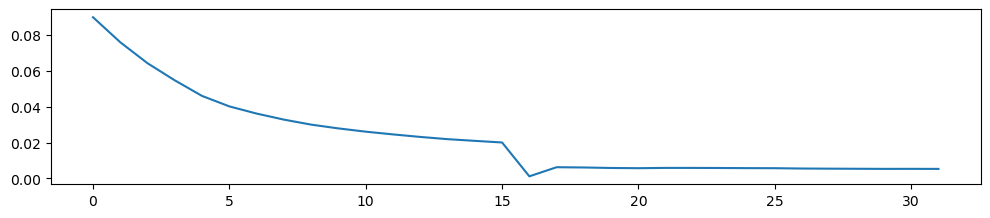

In [25]:
cost=torch.tensor(cost)
plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

Total accuracy:96.870%
accuracy0:99.184%
accuracy1:99.471%
accuracy2:96.221%
accuracy3:93.564%
accuracy4:98.371%
accuracy5:97.534%
accuracy6:96.451%
accuracy7:97.957%
accuracy8:96.715%
accuracy9:93.062%


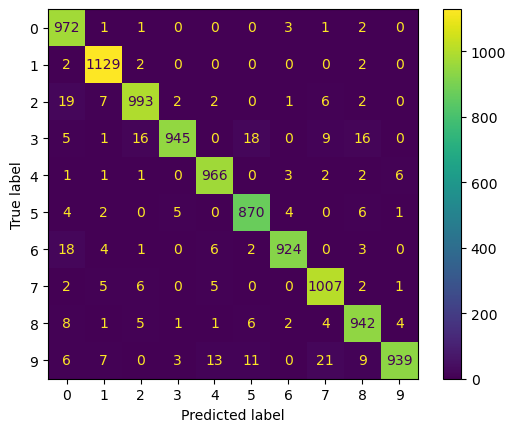

In [26]:
# validation
y_pred=[]
y_true=[]
for i,(xbatch,ybatch) in enumerate(test_loader):
    # farward pass
    ypred= model(xbatch)
    ypred= torch.argmax(ypred,dim=1)
    y_pred.extend(ypred.numpy())
    y_true.extend(torch.argmax(ybatch,dim=1).numpy())
    
y_pred= np.array(y_pred)
y_true= np.array(y_true)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(y_true,y_pred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(C.shape[0]):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()